In [3]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

import numpy as np

In [4]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5,), (0.5,))])

batch_size = 1

classes = range(2)

In [5]:
batch_size = 1
n_train = 100

# Use pre-defined torchvision function to load MNIST train data
X_test = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
idx = np.append(
    np.where(X_test.targets == 0)[0][n_train:], np.where(X_test.targets == 1)[0][n_train:]
)
X_test.data = X_test.data[idx]
X_test.targets = X_test.targets[idx]


testloader = torch.utils.data.DataLoader(X_test, batch_size=batch_size, shuffle=True)

In [6]:
print(len(testloader))

12465


In [7]:
def test_acc(net):
    errors = []

    correct = 0
    total = 0
    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            # calculate outputs by running images through the network
            outputs = net(images)
            # the class with the highest energy is what we choose as prediction
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            for i in range(len(predicted)):
                if labels[i] != predicted[i]:
                    errors.append(images[i])

    return correct / total, errors

In [8]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

In [9]:
def ensemble(models):
    def predict(images):
        predictions = torch.zeros((len(images), len(classes)))
        for model in models:
            y = model(images)
            outputs = torch.zeros(y.shape)
            for i in range(len(outputs)):
                outputs[i][torch.argmax(y[i])] = 1.
            predictions += outputs
        return predictions
    
    return predict

# Single Classical

In [12]:
from models.cnet import SNet, CNet

arch = CNet

In [13]:
PATH = './trained_models/clnet.pth'
net = arch()
net.load_state_dict(torch.load(PATH))

<All keys matched successfully>

In [14]:
acc, errors = test_acc(net)
print(f'Accuracy of the model on the test images: {100 * acc} %')

Accuracy of the model on the test images: 99.70316887284396 %


Incorrectly predicted images


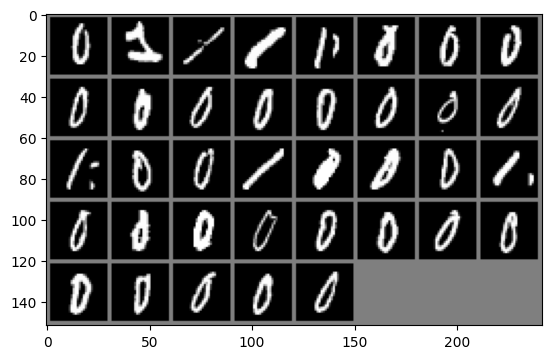

In [15]:
print("Incorrectly predicted images")
imshow(torchvision.utils.make_grid(errors))

# Single Quantum

In [87]:
from models.qnet import QSNet

arch = QSNet

In [88]:
PATH = './trained_models/qnet.pth'
net = arch()
net.load_state_dict(torch.load(PATH))

<All keys matched successfully>

In [89]:
acc, errors = test_acc(net)
print(f'Accuracy of the model on the test images: {100 * acc} %')

/Users/petergao/Documents/GitHub/Quantum/Digit-Classifier/models/qnet.py:193: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = F.softmax(x)


Accuracy of the model on the test images: 99.7513036502206 %


Incorrectly predicted images


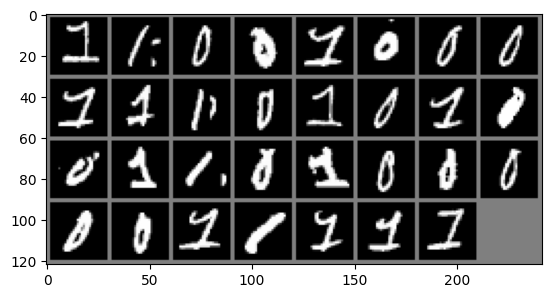

In [91]:
print("Incorrectly predicted images")
imshow(torchvision.utils.make_grid(errors))

# TODO

# Classical Ensemble

In [64]:
arch = SNet

In [84]:
saved_models = []
last_model = arch()
for i in range(5):
    saved_model = arch()

    PATH = f'./trained_models/clnet{i}.pth'
    saved_model.load_state_dict(torch.load(PATH))
    saved_models.append(saved_model)

net = ensemble(saved_models)

False
False
False
False
False


In [85]:
acc, errors = test_acc(net)
print(f'Accuracy of the model on the test images: {100 * acc} %')

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
Fals

/Users/petergao/Documents/GitHub/Quantum/Digit-Classifier/models/cnet.py:23: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = F.softmax(x)


False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
Fals

KeyboardInterrupt: 

Incorrectly predicted images


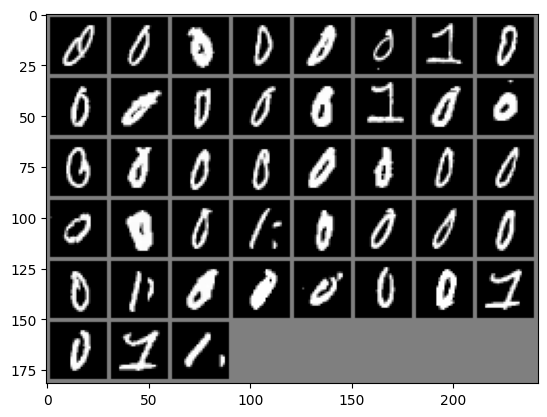

In [44]:
print("Incorrectly predicted images")
imshow(torchvision.utils.make_grid(errors))

# Quantum Ensemble

In [45]:
arch = QSNet

In [46]:
saved_models = []

for i in range(5):
    saved_model = arch()

    PATH = f'./trained_models/qnet{i}.pth'
    saved_model.load_state_dict(torch.load(PATH))
    saved_models.append(saved_model)

net = ensemble(saved_models)

In [47]:
acc, errors = test_acc(net)
print(f'Accuracy of the model on the test images: {100 * acc} %')

/Users/petergao/Documents/GitHub/Quantum/Digit-Classifier/models/qnet.py:193: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = F.softmax(x)


Accuracy of the model on the test images: 99.59887685519455 %


Incorrectly predicted images


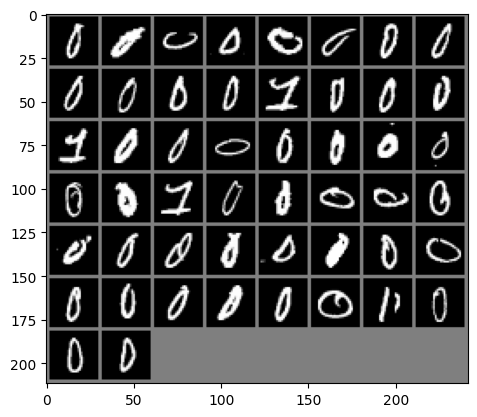

In [48]:
print("Incorrectly predicted images")
imshow(torchvision.utils.make_grid(errors))